In [ ]:
import numpy as np

In [ ]:
GLOBAL_SEED = 24
rng = np.random.default_rng(GLOBAL_SEED)

def reset_seed(seed = GLOBAL_SEED):
    global rng
    rng = np.random.default_rng(seed)

In [ ]:
def shuffle_data(arr1, arr2):
    assert len(arr1) == len(arr2), "Arrays must have the same length"
    permutation = rng.permutation(len(arr1))
    reset_seed()
    return arr1[permutation], arr2[permutation]

In [ ]:
class WeightInitializer:       
    @staticmethod
    def zeros(shape):
        """Initialize weights with all zeros."""
        return np.zeros(shape)

    @staticmethod
    def uniform(shape, low=-0.5, high=0.5):
        """Initialize weights with a uniform distribution."""
        return rng.uniform(low, high, shape)

    @staticmethod
    def normal(shape, mean=0.0, std=0.5):
        """Initialize weights with a normal distribution."""
        return rng.normal(mean, std, shape)

    @staticmethod
    def xavier(shape, fan_in, fan_out):
        """Initialize weights using Xavier (Glorot) initialization (normal)."""
        std = np.sqrt(2 / (fan_in + fan_out))
        return rng.normal(0, std, shape)
    
    @staticmethod
    def xavier_uniform(shape, fan_in, fan_out):
        """Initialize weights using Xavier (Glorot) initialization (uniform)."""
        limit = np.sqrt(6 / (fan_in + fan_out))
        return rng.uniform(-limit, limit, shape)

    @staticmethod
    def kaiming(shape, fan_in):
        """Initialize weights using Kaiming (He) initialization."""
        std = np.sqrt(2 / fan_in)
        return np.random.normal(0, std, size=shape)

    @staticmethod
    def kaiming_uniform(shape, fan_in):
        """He uniform initialization for ReLU layers"""
        limit = np.sqrt(6 / fan_in)
        return rng.uniform(-limit, limit, shape)

# -------------------------
# Activation functions
# -------------------------

class ReLU:
    @staticmethod
    def activate(x):
        return np.maximum(0, x)
    
    @staticmethod
    def derivative(x):
        return (x > 0).astype(float)

class Sigmoid:
    @staticmethod
    def activate(x):
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def derivative(x):
        s = Sigmoid.activate(x)
        return s * (1 - s)
    
class Linear:
    @staticmethod
    def activate(x):
        return x

    @staticmethod
    def derivative(x):
        return np.ones_like(x)

class Tanh:
    @staticmethod
    def activate(x):
        return np.tanh(x)
    
    @staticmethod
    def derivative(x):
        return 1 - np.tanh(x)**2

class Softmax:
    @staticmethod
    def activate(x):
        # e = np.exp(x - np.max(x))
        # return e / np.sum(e)
        
        exp_x = np.exp(x - np.max(x))  # stability trick
        return exp_x / np.sum(exp_x)
        
        # shifted_x = x - np.max(x, axis=-1, keepdims=True)
        # exp_x = np.exp(shifted_x)
        
        # sum_exp = np.sum(exp_x, axis=-1, keepdims=True)
        # sum_exp = np.clip(sum_exp, 1e-15, None)
        # return exp_x / sum_exp

In [ ]:
# -------------------------
# Loss functions
# -------------------------

class MSELoss:  # Do not use with Softmax activation!!
    @staticmethod
    def loss(y_pred, y_true):
        return np.mean((y_pred - y_true)**2)

    @staticmethod
    def output_delta(y_pred, y_true, z, activation):
        return (y_pred - y_true) * activation.derivative(z)  


class CrossEntropyLoss:  # Only use with Softmax activation!!
    @staticmethod
    def loss(y_pred, y_true):
        epsilon = 1e-15  # avoid log(0)
        y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))  # np.mean is used if we're updating batch by batch

    @staticmethod
    def output_delta(y_pred, y_true, z, activation):  # activation should be Softmax
        if activation != Softmax:
            raise ValueError("Cross Entropy Loss should be used with Softmax activation in the output layer.")
        
         # Softmax + Cross Entropy has a simplified formula for delta
        return y_pred - y_true  # y_pred is post-activation function

In [ ]:
# -------------------------
# Linear Layer
# -------------------------

class LinearLayer:
    def __init__(self, n_in, n_out, weights_type):
        self.shape = (n_in, n_out)
        
        # self.W = np.random.randn(n_in, n_out) * np.sqrt(2/n_in)
        self.W = self.initialize_weights(self.shape, weights_type, n_in, n_out)
        reset_seed()
        self.b = np.zeros((n_out,))
        
        # store previous weight updates (difference between current weights and the previous weights). used for momentum
        self.previous_dW = np.zeros_like(self.W)
        self.previous_db = np.zeros_like(self.b)
        
        
    def initialize_weights(self, shape, weights_type, n_in, n_out):        
        # Map weight types to their corresponding methods
        weight_methods = {
            'zero': WeightInitializer.zeros,
            'uniform': WeightInitializer.uniform,
            'normal': WeightInitializer.normal,
            'xavier': lambda s: WeightInitializer.xavier(s, n_in, n_out),
            'xavier-uniform': lambda s: WeightInitializer.xavier_uniform(s, n_in, n_out),
            'kaiming': lambda s: WeightInitializer.kaiming(s, n_in),
            'kaiming-uniform': lambda s: WeightInitializer.kaiming_uniform(s, n_in),
        }
        # Default to Xavier if the type is not recognized
        return weight_methods.get(weights_type, lambda s: WeightInitializer.xavier(s, n_in, n_out))(shape)


    def forward(self, x):
        self.x = x          # store input
        self.z = x @ self.W + self.b  # store pre-activation
        return self.z

    def __str__(self):
        return f"LinearLayer(shape={self.shape})"

In [ ]:

# -------------------------
# MLP with Delta-Based Backprop
# -------------------------
class MLP:
    def __init__(self, layer_sizes, activations, loss="mse", lr=0.01, momentum=0, weights_type="xavier"):
        self.layers = []
        self.activations = []
        self.train_loss_list , self.test_loss_list = [], []
        self.train_psnr_list , self.test_psnr_list = [], []
        
        self.lr = lr
        self.momentum = momentum
        self.loss_fn = CrossEntropyLoss if loss == "cross_entropy" else MSELoss

        self.weights_type = weights_type.strip().lower()
        
        for i in range(len(layer_sizes) - 1):
            self.layers.append(
                LinearLayer(layer_sizes[i], layer_sizes[i + 1], weights_type)
            )
            # if activations[i] is not None:
            #     self.activations.append(activations[i])
            # else:
            #     self.activations.append(None)
            
            self.activations.append(activations[i] if activations[i] is not None else None)
        
                

    def forward(self, x):
        out = x
        self.z = []  # pre-activation outputs
        self.a = [x]  # post-activation outputs, starting with input

        for layer, activation in zip(self.layers, self.activations):
            z = layer.forward(out)
            self.z.append(z)

            out = z if activation is None else activation.activate(z)
            self.a.append(out)

        return out


    def backward(self, batch_X, batch_Y):
        # gradient accumulators - these will store the sum of the gradients for each weight
        dW_batch = [np.zeros_like(layer.W) for layer in self.layers]
        db_batch = [np.zeros_like(layer.b) for layer in self.layers]

        batch_size = len(batch_X)
        batch_loss = 0

        # calculate gradients (dW) for each sample in batch and accumulate them
        for x, y in zip(batch_X, batch_Y):
            x = x.reshape(1, -1)
            y = y.reshape(1, -1)

            y_pred = self.forward(x)
            batch_loss += self.loss_fn.loss(y_pred, y)

            deltas = [None] * len(self.layers)
            deltas[-1] = self.loss_fn.output_delta(
            y_pred, y, self.z[-1], self.activations[-1]
            )

            # find hidden layer deltas
            for i in reversed(range(len(self.layers)-1)):
                W_next = self.layers[i+1].W
                delta_next = deltas[i+1]
                z = self.z[i]
                deltas[i] = (delta_next @ W_next.T) * \
                            self.activations[i].derivative(z)

            # store (accumulate) gradients for each weight
            for i, (layer, delta) in enumerate(zip(self.layers, deltas)):
                x_i = self.a[i]
                dW_batch[i] += x_i.reshape(-1,1) @ delta.reshape(1,-1)  # x * delta
                db_batch[i] += delta.reshape(-1)

        # Average gradients for every weight 
        dW_batch = [dW / batch_size for dW in dW_batch]
        db_batch = [db / batch_size for db in db_batch]

        # Update
        for i, layer in enumerate(self.layers):
            layer.W = layer.W - self.lr * dW_batch[i] + self.momentum * layer.previous_dW
            layer.b = layer.b - self.lr * db_batch[i] + self.momentum * layer.previous_db
            layer.previous_dW = layer.W - layer.previous_dW
            layer.previous_db = layer.b - layer.previous_db
                  
        return batch_loss


    def train(self, X, Y, epochs=10, print_interval=2, batch_size=1, shuffle=False,
              test_model=False, X_test=None, Y_test=None):
        
        N = len(X)
        
        if shuffle:
            X, Y = shuffle_data(X, Y)
        
        for epoch in range(epochs):  # Loop over epochs
            epoch_loss = 0
            
            for start in range(0, N, batch_size):  # Loop over batches
                end = start + batch_size
                X_batch = X[start:end]
                Y_batch = Y[start:end]
                
                # print(f"Batch {(start//batch_size) + 1}")
                
                # for x, y in zip(X_batch, Y_batch):  # Loop over samples in batch
                #     x = x.reshape(1, -1)
                #     y = y.reshape(1, -1)

                #     y_pred = self.forward(x)
                #     epoch_loss += self.loss_fn.loss(y_pred, y)
                    
                epoch_loss += self.backward(X_batch, Y_batch)  # find grads (dw) after each sample and store them
                
                # self.update_weights()  # weights are updated after each batch
                
            train_loss = epoch_loss/N
            self.train_loss_list.append(train_loss)
            
            if test_model:
                test_loss = self.test(X_test, Y_test)
                self.test_loss_list.append(test_loss)
            
            if (epoch + 1) % print_interval == 0:
                print(f"Epoch {epoch+1:4},   Train Loss: {train_loss:6f}", end='')
                if test_model:
                    print(f",   Test Loss: {test_loss:6f}", end='')
                print()
    

    def test(self, X, Y):
            loss_sum = 0
            for x, y in zip(X, Y):
                x = x.reshape(1, -1)
                y = y.reshape(1, -1)

                y_pred = self.forward(x)
                loss_sum += self.loss_fn.loss(y_pred, y)
            
            return loss_sum/len(X)


    def __str__(self):
        network_architecture = ""
        for layer, activation in zip(self.layers, self.activations):
            network_architecture += f"Linear Block {layer.shape}, Activation: {activation.__name__ if activation else 'None'}\n"

        return (
            f"Network Details:\n"
            f"Input Size: {self.layers[0].shape[0]}\n"
            f"Output Size: {self.layers[-1].shape[-1]}\n"
            f"Architecture:\n{network_architecture}"
            f"Learning Rate: {self.lr}\n"
            f"Weight Initialization Type: {self.weights_type}\n"
        )

### Example 1

In [ ]:
# -------------------------
# Example usage (XOR)
# -------------------------


X = np.array([[0,0],
                [0,1],
                [1,0],
                [1,1]])

Y = np.array([[0],
                [1],
                [1],
                [0]])

model = MLP(
    layer_sizes=[2, 4, 1],
    activations=[ReLU, Sigmoid],
    loss="mse",
    lr=0.1
)


In [ ]:
print(model)

In [ ]:
model.forward([1,0])

In [ ]:
model.train(X, Y, epochs=500, print_interval=100)

In [ ]:
model.forward([1,0])

### Example 2

In [2]:
import pandas as pd
import numpy as np
from MLP import MLP, ReLU, Sigmoid, Softmax, CrossEntropyLoss, MSELoss, shuffle_data, reset_seed, plot_metric_over_epoch

df = pd.read_csv('seeds_dataset.csv')
df = df.sample(frac=1)
df.head(1)

,var1,var2,var3,var4,var5,var6,var7,class
121,18.14,16.12,0.8772,6.059,3.563,3.619,6.011,2


In [3]:
y = df['class']
X = df.drop('class', axis=1)

In [4]:
y = pd.get_dummies(y).astype('int')
y = y.to_numpy()
X = X.to_numpy()

In [30]:
import math
thresh =  math.ceil(0.8 * len(X))

X_train = X[:thresh]
y_train = y[:thresh]

X_test = X[thresh:]
y_test = y[thresh:]

print(len(X_train))
print(len(X_test))

168
42


In [31]:
model = MLP(
    layer_sizes=[7, 16, 32, 16, 8, 3],
    activations=[ReLU(), ReLU(), ReLU(), Sigmoid()],
    loss="mse",
    lr=0.001,
    momentum=0.5,
    weight_type="kaiming-uniform"
)

print(model)


Multi-Layer Perceptron Details:
Input Size: 7
Output Size: 3
Architecture:
  Layer  1: Linear Block (7, 16),   Activation: ReLU
  Layer  2: Linear Block (16, 32),   Activation: ReLU
  Layer  3: Linear Block (32, 16),   Activation: ReLU
  Layer  4: Linear Block (16, 8),   Activation: Sigmoid
  Layer  5: Linear Block (8, 3),   Activation: Linear
Learning Rate: 0.001
Momentum: 0.5
Weight Initialization Type: kaiming-uniform



In [32]:
model.train(X_train, y_train, epochs=100, print_interval=10, batch_size=1,
            test_model=True, X_test=X_test, Y_test=y_test)

Training:   0%|          | 0/100 [00:00<?, ?Epoch/s]

Epoch   10 /  100,   Train Loss: 0.149366,   Test Loss: 0.144090
Epoch   20 /  100,   Train Loss: 0.131827,   Test Loss: 0.123453
Epoch   30 /  100,   Train Loss: 0.121398,   Test Loss: 0.110726
Epoch   40 /  100,   Train Loss: 0.114310,   Test Loss: 0.102867
Epoch   50 /  100,   Train Loss: 0.108467,   Test Loss: 0.096424
Epoch   60 /  100,   Train Loss: 0.101808,   Test Loss: 0.090204
Epoch   70 /  100,   Train Loss: 0.096795,   Test Loss: 0.085962
Epoch   80 /  100,   Train Loss: 0.092404,   Test Loss: 0.081576
Epoch   90 /  100,   Train Loss: 0.088508,   Test Loss: 0.077405
Epoch  100 /  100,   Train Loss: 0.085117,   Test Loss: 0.073991
Training completed in 3.42 seconds.


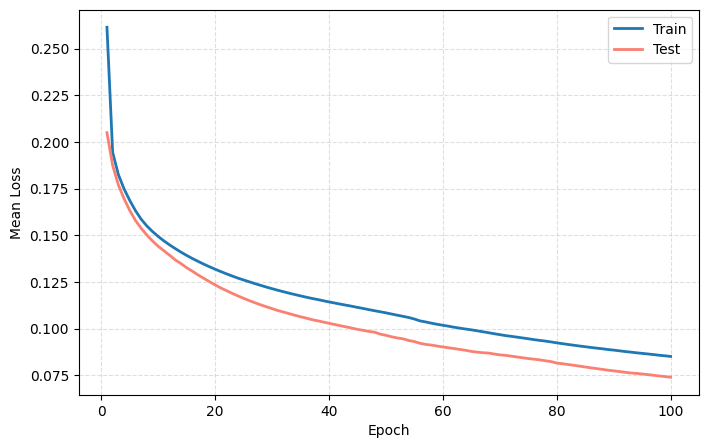

In [34]:
plot_metric_over_epoch(model.train_loss_list, model.test_loss_list)

In [36]:
results = model.forward(X_test)

In [41]:
np.mean((results - y_test)**2)

np.float64(0.07399141702195322)

In [43]:
(results[0] - y_test[0])**2

array([0.06799592, 0.01311723, 0.10787333])

In [ ]:
v = model.forward(X[130])
print(v)

In [ ]:
np.max(v)

In [ ]:
y[130]

In [ ]:
df.info()

## PSNR

Training  samples  of  blocks  are  converted  
into  vectors  and  then  normalized  from  their  gray-level  range  
into [0, 1]

In [ ]:
def calculate_psnr(image1, image2):
    """
    Calculate the PSNR (Peak Signal-to-Noise Ratio) between two grayscale images.

    Parameters:
        image1 (numpy.ndarray): First image with values in [0, 1].
        image2 (numpy.ndarray): Second image with values in [0, 1].

    Returns:
        float: PSNR value in decibels (dB).
    """
    if image1.shape != image2.shape:
        raise ValueError("Input images must have the same dimensions.")
    
    mse = np.mean((image1 - image2) ** 2)
    if mse == 0:
        return float('inf')  # PSNR is infinite if images are identical
    
    max_pixel_value = 1.0  # Since the images are in [0, 1]
    psnr = 20 * np.log10(max_pixel_value / np.sqrt(mse))
    return psnr

In [ ]:
import numpy as np
calculate_psnr(np.array([1, 0, 0.5]), np.array([1, 0.5, 0]))

## experiments

In [ ]:
A = np.array( [[2, 3], [6, 8]])
B = np.array([[1, 0], [0, 5]])
A - B

In [ ]:

# -------------------------
# Example usage (XOR)
# -------------------------

if __name__ == "__main__":
    X = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])

    Y = np.array([[0],
                  [1],
                  [1],
                  [0]])

    model = MLP(
        layer_sizes=[2, 4, 4, 1],
        activations=[ReLU(), ReLU(), Sigmoid()],
        loss="mse",
        lr=0.1,
        use_momentum=True,
        momentum=0.9
    )

    model.train(X, Y, epochs=5, batch_size=2)  # SGD
